In [21]:
!pip -q install tensorflow==2.19.1 nibabel matplotlib scikit-image

# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import transform
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, Add, Flatten, Dense, LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.callbacks import Callback
from IPython.display import clear_output
from google.colab import drive
import random
from tensorflow.keras.regularizers import l2  # Import L2 regularization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, Add, Flatten, Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from IPython.display import clear_output
from tensorflow.keras.regularizers import l2  # Import L2 regularization

from tensorflow.keras.layers import Dropout  # Ensure Dropout is imported

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras import regularizers
from keras.metrics import Precision, Recall


In [22]:

# List all available GPUs
gpus = tf.config.list_physical_devices('GPU')

# Set TensorFlow to allocate all memory upfront for each GPU
if gpus:
    try:
        for gpu in gpus:
            # Set memory growth to False
            tf.config.experimental.set_memory_growth(gpu, False)
    except RuntimeError as e:
        # This exception is raised when the GPU is already initialized; in this case, memory growth can't be changed.
        print(e)

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [23]:
### FOR T2 + FLAIR
# Mount Google Drive
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Data loading and preprocessing functions
def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def preprocess_data(image, resize_target=(300, 300), pad_target=(320, 320)):
    """Normalize, resize, and pad a single slice of MRI data."""
    normalized = image / np.max(image) if np.max(image) > 0 else image
    resized = resize(normalized, resize_target, anti_aliasing=True)
    padded = pad_image_to_size(resized, *pad_target)
    return padded


def pad_image_to_size(image, target_height=320, target_width=320, mode='constant'):
    """Pad the image to the target height and width."""
    current_height, current_width = image.shape[:2]
    delta_h = max(target_height - current_height, 0)
    delta_w = max(target_width - current_width, 0)
    top_pad = delta_h // 2
    bottom_pad = delta_h - top_pad
    left_pad = delta_w // 2
    right_pad = delta_w - delta_w // 2
    padding = ((top_pad, bottom_pad), (left_pad, right_pad))
    padded_image = np.pad(image, padding, mode=mode)
    return padded_image

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
### MODEL 3 ###

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Add, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.regularizers import l2

def basic_block(x, filter_num, stride=1):
    """ Basic block for ResNet with two convolutional layers and a skip connection. """
    y = Conv2D(filter_num, (3, 3), strides=stride, padding='same', kernel_regularizer=l2(0.0005))(x)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    y = Conv2D(filter_num, (3, 3), strides=1, padding='same', kernel_regularizer=l2(0.0005))(y)
    y = BatchNormalization()(y)

    if stride != 1:
        x = Conv2D(filter_num, (1, 1), strides=stride, padding='same', kernel_regularizer=l2(0.0005))(x)
    out = Add()([x, y])
    out = Activation('relu')(out)
    return out

def build_resnet(input_shape=(320, 320, 1), num_classes=1):
    inputs = Input(shape=input_shape)

    # Initial convolutional layer
    x = Conv2D(16, (3, 3), strides=1, padding='same', kernel_regularizer=l2(0.0005))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Stacking basic blocks
    x = basic_block(x, 16, stride=1)
    x = basic_block(x, 32, stride=2)
    x = basic_block(x, 64, stride=2)
    x = basic_block(x, 128, stride=2)

    # Global Average Pooling and Dense layer for classification
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Creating the ResNet model
#resnet_model = build_resnet()
#resnet_model.summary()





In [25]:
def basic_block(x, filter_num, stride=1):
    """Basic block for ResNet with two convolutional layers and a skip connection."""
    y = Conv2D(filter_num, (3, 3), strides=stride, padding='same', kernel_regularizer=l2(0.0005))(x)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    y = Conv2D(filter_num, (3, 3), strides=1, padding='same', kernel_regularizer=l2(0.0005))(y)
    y = BatchNormalization()(y)

    if stride != 1:
        x = Conv2D(filter_num, (1, 1), strides=stride, padding='same', kernel_regularizer=l2(0.0005))(x)
    out = Add()([x, y])
    out = Activation('relu')(out)
    return out

def build_resnet(input_shape=(320, 320, 1), num_classes=1):
    inputs = Input(shape=input_shape)

    # Initial convolutional layer
    x = Conv2D(16, (3, 3), strides=1, padding='same', kernel_regularizer=l2(0.0005))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Stacking basic blocks
    x = basic_block(x, 16, stride=1)
    x = basic_block(x, 32, stride=2)
    x = basic_block(x, 64, stride=2)
    x = basic_block(x, 128, stride=2)

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Additional Dense layer
    x = Dense(512, activation='relu')(x)  # Adding a Dense layer with 512 units and ReLU activation

    # Output layer
    outputs = Dense(num_classes, activation='sigmoid')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [26]:
class PlotLosses(Callback):
    def on_train_begin(self, logs=None):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_acc = []
        self.f1s = []
        self.val_f1s = []
        self.logs = []
        self.fig = plt.figure()

    def on_epoch_end(self, epoch, logs=None):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.acc.append(logs.get('accuracy'))
        self.val_acc.append(logs.get('val_accuracy'))

        precision = logs.get('precision')
        recall = logs.get('recall')
        f1 = 2 * (precision * recall) / (precision + recall) if precision is not None and recall is not None and precision + recall > 0 else 0
        self.f1s.append(f1)

        val_precision = logs.get('val_precision')
        val_recall = logs.get('val_recall')
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall) if val_precision is not None and val_recall is not None and val_precision + val_recall > 0 else 0
        self.val_f1s.append(val_f1)

        self.i += 1

        # Plot every 3 epochs
        if self.i % 1 == 0:
            clear_output(wait=True)
            plt.subplot(3, 1, 1)
            plt.plot(self.x, self.losses, label="Training loss")
            plt.plot(self.x, self.val_losses, label="Validation loss")
            plt.legend()
            plt.title('Training and Validation Loss')

            plt.subplot(3, 1, 2)
            plt.plot(self.x, self.acc, label="Training accuracy")
            plt.plot(self.x, self.val_acc, label="Validation accuracy")
            plt.legend()
            plt.title('Training and Validation Accuracy')

            plt.subplot(3, 1, 3)
            plt.plot(self.x, self.f1s, label="Training F1 Score")
            plt.plot(self.x, self.val_f1s, label="Validation F1 Score")
            plt.legend()
            plt.title('Training and Validation F1 Score')

            plt.tight_layout()
            plt.show()


In [27]:

# Define the early stopping callback
early_stopper = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    min_delta=0.01,      # Minimum change to qualify as an improvement
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    verbose=1,            # Output messages
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

FLAIR slices: 1451
T2 slices:    1380


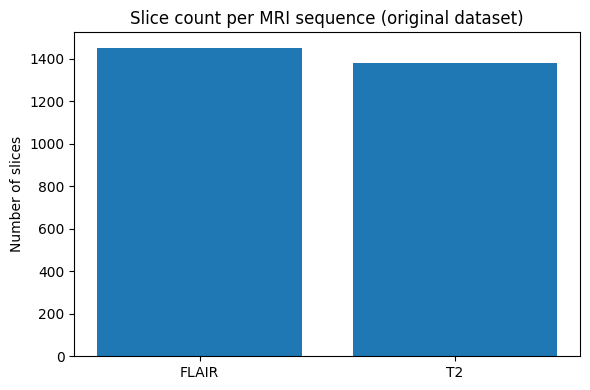

In [28]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

def count_flair_t2_slices(base_path, num_patients):
    flair_slices = 0
    t2_slices = 0

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(
            base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii'
        )
        t2_path = os.path.join(
            base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii'
        )

        # Load NIfTI headers only (cheap)
        flair_img = nib.load(flair_path)
        t2_img = nib.load(t2_path)

        flair_slices += flair_img.shape[2]
        t2_slices += t2_img.shape[2]

    return flair_slices, t2_slices


# --- run ---
num_patients = 60
flair_count, t2_count = count_flair_t2_slices(base_path, num_patients)

print(f"FLAIR slices: {flair_count}")
print(f"T2 slices:    {t2_count}")

# Plot histogram
plt.figure(figsize=(6, 4))
plt.bar(["FLAIR", "T2"], [flair_count, t2_count])
plt.ylabel("Number of slices")
plt.title("Slice count per MRI sequence (original dataset)")
plt.tight_layout()
plt.show()


    FLAIR_MS: 787
  FLAIR_NoMS: 664
       T2_MS: 643
     T2_NoMS: 737


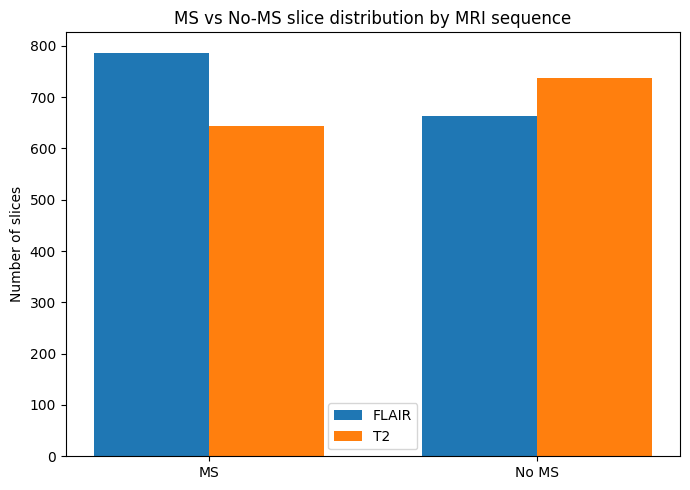

In [29]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def count_ms_by_modality(base_path, num_patients):
    stats = {
        "FLAIR_MS": 0,
        "FLAIR_NoMS": 0,
        "T2_MS": 0,
        "T2_NoMS": 0,
    }

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii')
        seg_flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')
        seg_t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-T2.nii')

        flair_img = nib.load(flair_path).get_fdata()
        t2_img = nib.load(t2_path).get_fdata()
        seg_flair = nib.load(seg_flair_path).get_fdata()
        seg_t2 = nib.load(seg_t2_path).get_fdata()

        # FLAIR slices
        for z in range(flair_img.shape[2]):
            if np.max(seg_flair[:, :, z]) > 0:
                stats["FLAIR_MS"] += 1
            else:
                stats["FLAIR_NoMS"] += 1

        # T2 slices
        for z in range(t2_img.shape[2]):
            if np.max(seg_t2[:, :, z]) > 0:
                stats["T2_MS"] += 1
            else:
                stats["T2_NoMS"] += 1

    return stats


# --- run ---
stats = count_ms_by_modality(base_path, num_patients)

for k, v in stats.items():
    print(f"{k:>12}: {v}")

# Prepare plot
labels = ["MS", "No MS"]
flair_counts = [stats["FLAIR_MS"], stats["FLAIR_NoMS"]]
t2_counts = [stats["T2_MS"], stats["T2_NoMS"]]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, flair_counts, width, label="FLAIR")
plt.bar(x + width/2, t2_counts, width, label="T2")

plt.xticks(x, labels)
plt.ylabel("Number of slices")
plt.title("MS vs No-MS slice distribution by MRI sequence")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#### FOR T2+ FLAIR SKIPPPPPPPPPPP IF DATA SAVED

def compile_data(base_path, num_patients):
    """Compile the image data and create binary labels for MS presence."""
    combined_images = []
    ms_labels = []

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii')
        seg_flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')
        seg_t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-T2.nii')

        flair_img = load_nii(flair_path)
        t2_img = load_nii(t2_path)
        ms_flair_img = load_nii(seg_flair_path)
        ms_t2_img = load_nii(seg_t2_path)

        for slice_idx in range(flair_img.shape[2]):
            flair_slice = flair_img[:, :, slice_idx]
            ms_slice = ms_flair_img[:, :, slice_idx]

            flair_processed = preprocess_data(flair_slice)
            combined_images.append(flair_processed)

            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)


        for slice_idx in range(t2_img.shape[2]):
            t2_slice = t2_img[:, :, slice_idx]
            ms_slice = ms_t2_img[:, :, slice_idx]
            t2_processed = preprocess_data(t2_slice)
            combined_images.append(t2_processed)
            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

    X = np.array(combined_images)
    Y = np.array(ms_labels)

    return X, Y

num_patients = 60  # Total number of patients
X, Y = compile_data(base_path, num_patients)

base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data'

# Ensure the directory exists
os.makedirs(base_save_path, exist_ok=True)

# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y.npy'), Y)

KeyboardInterrupt: 

In [ ]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y.npy'), Y)

NameError: name 'X' is not defined

In [10]:
# Load the saved data
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset'
X = np.load(os.path.join(base_save_path, 'X.npy'))
Y = np.load(os.path.join(base_save_path, 'Y.npy'))

print("Data loaded successfully:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Data loaded successfully:
X shape: (2831, 320, 320)
Y shape: (2831,)


In [11]:
if X.ndim == 3:  # Assuming X.shape is (num_samples, height, width)
    X = np.expand_dims(X, axis=-1)  # Add channel dimension
print("New shape of X:", X.shape)


New shape of X: (2831, 320, 320, 1)


Data is normalized between 0 and 1.
Label distribution: {np.int64(0): np.int64(1401), np.int64(1): np.int64(1430)}


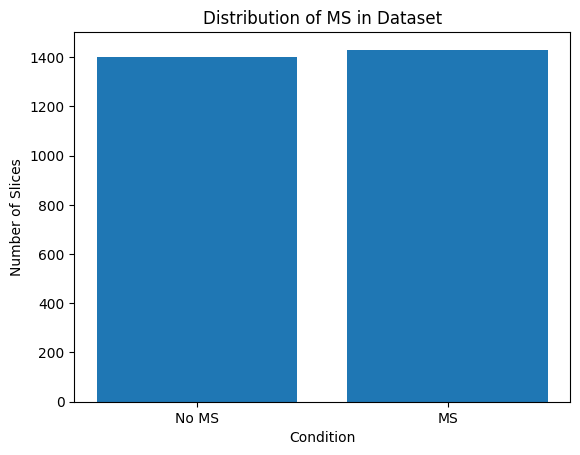

In [12]:

def check_normalization(data):
    min_val = np.min(data)
    max_val = np.max(data)
    if min_val >= 0 and max_val <= 1:
        print("Data is normalized between 0 and 1.")
        return True
    else:
        print(f"Data is not normalized properly. Min value: {min_val}, Max value: {max_val}")
        return False

# Example usage with your dataset X
is_normalized = check_normalization(X)
# Assuming Y is your array of labels
labels, counts = np.unique(Y, return_counts=True)
print("Label distribution:", dict(zip(labels, counts)))


plt.bar(labels, counts, tick_label=['No MS', 'MS'])
plt.xlabel('Condition')
plt.ylabel('Number of Slices')
plt.title('Distribution of MS in Dataset')
plt.show()


In [13]:
# Now split the data into training+validation (80%) and testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# Split the training and validation set (from the 80% "train_val" split, allocate 20% to validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

print("Adjusted Shape of X_train:", X_train.shape)  # Should be (1698, 320, 320, 1)
print("Adjusted Shape of X_val:", X_val.shape)      # Should be (566, 320, 320, 1)


Adjusted Shape of X_train: (1698, 320, 320, 1)
Adjusted Shape of X_val: (566, 320, 320, 1)


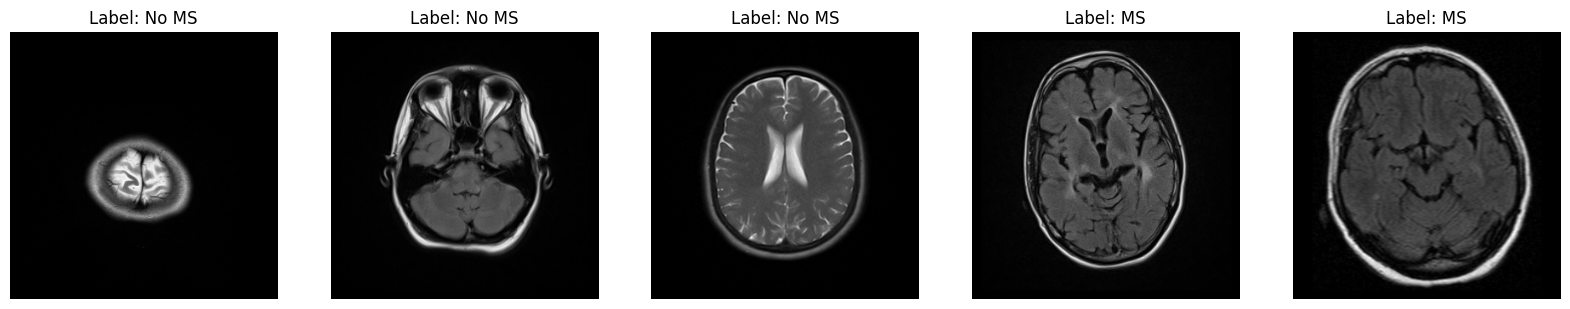

In [14]:
def visualize_sample_images(X, y, num_samples=5):
    """Randomly visualizes `num_samples` images from dataset `X` with their corresponding labels `y`."""
    indices = np.random.choice(range(len(X)), num_samples, replace=False)
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
    for i, idx in enumerate(indices):
        ax = axes[i]
        ax.imshow(X[idx].squeeze(), cmap='gray')  # Squeeze is used to remove single-dimensional entries from the shape of an array.
        ax.title.set_text(f'Label: {"MS" if y[idx] == 1 else "No MS"}')
        ax.axis('off')
    plt.show()

# Assuming X_train and y_train are your training data and labels loaded into the memory
visualize_sample_images(X_train, y_train)


In [15]:
# Assuming Y is your array of labels
labels, counts = np.unique(y_test, return_counts=True)
print("Label distribution:", dict(zip(labels, counts)))

Label distribution: {np.int64(0): np.int64(285), np.int64(1): np.int64(282)}


In [16]:
# Set the seed for NumPy and TensorFlow
np.random.seed(42)
tf.random.set_seed(42)



# Function to adjust the intensity of the image
def adjust_image_intensity_range(img, scale_range=(0.9, 1.1), shift_range=(-0.1, 0.1)):
    scale = np.random.uniform(*scale_range)
    shift = np.random.uniform(*shift_range)
    img = img * scale + shift
    return img

# Function to add random noise to the image
def add_random_noise(img, noise_level=0.05):
    noise = np.random.normal(0, noise_level, img.shape)
    img = img + noise
    return img

# Function to apply motion blur to the image
def apply_motion_blur(img, max_kernel_size=5):
    # Apply horizontal motion blur
    size = np.random.randint(1, max_kernel_size)
    kernel_motion_blur = np.zeros((size, size))
    kernel_motion_blur[int((size-1)/2), :] = np.ones(size)
    kernel_motion_blur = kernel_motion_blur / size
    img = cv2.filter2D(img, -1, kernel_motion_blur)
    return img

# Function to apply affine transformation
def apply_affine_transform(img, intensity=0.1):
    transform_matrix = transform.AffineTransform(scale=(1-intensity, 1-intensity), rotation=np.random.uniform(-intensity, intensity), translation=(img.shape[0]*np.random.uniform(-intensity, intensity), img.shape[1]*np.random.uniform(-intensity, intensity)))
    img = transform.warp(img, transform_matrix)
    return img
import numpy as np
from keras.preprocessing.image import img_to_array, array_to_img

def random_zoom_out(img, original_size=(320, 320), max_scale=1):
    # Choose a random scale factor between the maximum scale and 1 (inclusive)
    scale_factor = np.random.uniform(max_scale, 1.0)
    new_size = (int(original_size[0] * scale_factor), int(original_size[1] * scale_factor))

    # Resize the image
    img = img_to_array(img)  # Ensure it's an array
    img_resized = array_to_img(img).resize(new_size)

    # Convert back to array and pad to original size
    img_resized = img_to_array(img_resized)

    # Calculate padding size
    pad_height = (original_size[0] - new_size[0]) // 2
    pad_width = (original_size[1] - new_size[1]) // 2

    # Pad using 'edge' mode to mimic 'nearest' fill_mode
    img_padded = np.pad(img_resized,
                        ((pad_height, original_size[0] - new_size[0] - pad_height),
                         (pad_width, original_size[1] - new_size[1] - pad_width),
                         (0, 0)),
                        'edge')
    if img_padded.ndim == 2:
        img_padded = np.expand_dims(img_padded, axis=-1)

    return img_padded



def custom_augmentation(img):
    # Define all possible augmentations in a list
    augmentations = [
    adjust_image_intensity_range,
    apply_motion_blur,
    #apply_affine_transform,
    #random_zoom_out
    ]

    # Randomly decide if only one augmentation will be applied (75% chance)
    if np.random.rand() < 0.25: # originally 0.75 now 100% of images will get only 1 data augmentation none will get a combo
        # Choose one augmentation randomly
        augmentation_to_apply = np.random.choice(augmentations, 1)[0]
        img = augmentation_to_apply(img)
    else:
        # Apply a combination of augmentations (25% chance)
        np.random.shuffle(augmentations)  # Shuffle the list of augmentations
        for augmentation in augmentations:
            if np.random.rand() > 0.5:
                img = augmentation(img)

    # Ensure the image has three dimensions
    if img.ndim == 2:
        img = np.expand_dims(img, axis=-1)

    return img



# ImageDataGenerator configuration
train_datagen = ImageDataGenerator(
                rotation_range=30,
    horizontal_flip=True,
    width_shift_range=0.08,
    height_shift_range=0.08,
    fill_mode='nearest',
    preprocessing_function=custom_augmentation  # Unified custom augmentation function
)


val_datagen = ImageDataGenerator()

# Generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)


In [ ]:
class PredictionCallback(Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs={}):
        # Predictions on the validation set
        val_preds = self.model.predict(self.validation_data[0])
        # Convert predictions to binary (0 or 1) using 0.5 as a threshold
        val_preds_binary = (val_preds > 0.5).astype(int)
        # Count the number of 0s and 1s
        unique, counts = np.unique(val_preds_binary, return_counts=True)
        prediction_counts = dict(zip(unique, counts))
        print(f'Validation predictions after epoch {epoch+1}: {prediction_counts}')

# When instantiating the callback, pass the validation data
val_data = val_generator.next()
prediction_callback = PredictionCallback(validation_data=val_data)




AttributeError: 'NumpyArrayIterator' object has no attribute 'next'

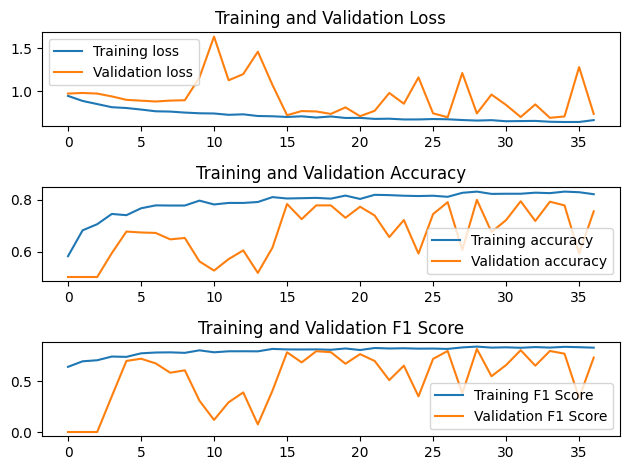

54/54 [==============================] - 12s 215ms/step - loss: 0.6691 - accuracy: 0.8221 - precision: 0.8142 - recall: 0.8443 - val_loss: 0.7402 - val_accuracy: 0.7562 - val_precision: 0.8069 - val_recall: 0.6690
Epoch 37: early stopping
18/18 [==============================] - 0s 25ms/step - loss: 0.7019 - accuracy: 0.7915 - precision: 0.7726 - recall: 0.8221
Evaluate right after training: Loss=0.7019099593162537, Accuracy=0.7915194630622864, Precision=0.7725752592086792, Recall=0.8220640420913696


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Semester 10/MS Dataset/My Models/ResNet.h5.npy'

In [ ]:
from keras.metrics import Precision, Recall
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D, Dense, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall
plot_losses = PlotLosses()
#model = build_vgg()
model = build_resnet()
#model.summary()
#model = build_alexnet()
# model = binary_classification_model()
# Compile the model with precision and recall as metrics
model.compile(optimizer=Adam(learning_rate=0.00005),
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# Assuming you have the `train_generator` and `val_generator`
# Fit the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[ early_stopper, plot_losses],
    verbose=1
)

# Evaluate the model
loss, accuracy, precision, recall = model.evaluate(val_generator)
print(f'Evaluate right after training: Loss={loss}, Accuracy={accuracy}, Precision={precision}, Recall={recall}')


# Save and reload the model
model.save('ResNet.h5')
del model  # Optional: to ensure the model is reloaded from file
model = load_model('ResNet.h5')
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/My Models'
# Save the arrays
np.save(os.path.join(base_save_path, 'ResNet.h5'), model)


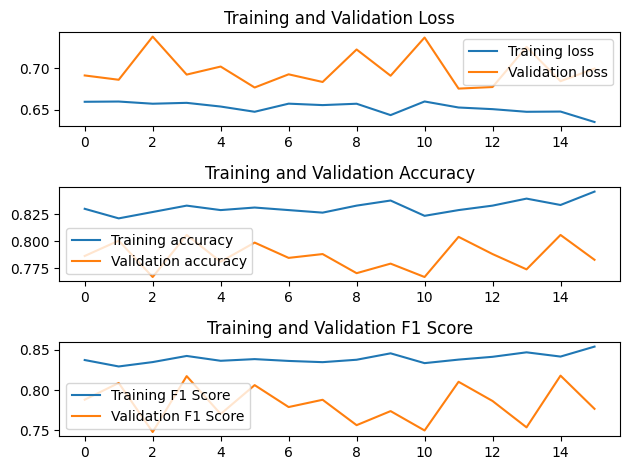

54/54 [==============================] - 14s 254ms/step - loss: 0.6354 - accuracy: 0.8457 - precision: 0.8270 - recall: 0.8824 - val_loss: 0.6998 - val_accuracy: 0.7827 - val_precision: 0.7926 - val_recall: 0.7616
Epoch 16: early stopping
18/18 [==============================] - 1s 27ms/step - loss: 0.6770 - accuracy: 0.7986 - precision: 0.7720 - recall: 0.8434
Evaluate right after training: Loss=0.6769904494285583, Accuracy=0.7985865473747253, Precision=0.7719869613647461, Recall=0.8434163928031921


In [ ]:
from keras.metrics import Precision, Recall
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, GlobalAveragePooling2D, Dense, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall
plot_losses = PlotLosses()
#model = build_vgg()
#model = build_resnet()
#model.summary()
#model = build_alexnet()
# model = binary_classification_model()
# Compile the model with precision and recall as metrics
#model.compile(optimizer=Adam(learning_rate=0.00001),
              #loss='binary_crossentropy',
              #metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# Assuming you have the `train_generator` and `val_generator`
# Fit the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=150,
    callbacks=[ early_stopper, plot_losses],
    verbose=1
)

# Evaluate the model
loss, accuracy, precision, recall = model.evaluate(val_generator)
print(f'Evaluate right after training: Loss={loss}, Accuracy={accuracy}, Precision={precision}, Recall={recall}')

In [ ]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/My Models'
# Save the arrays
np.save(os.path.join(base_save_path), model)

In [ ]:
print(f"Early stopping saved model at epoch {best_epoch + 1}")  # +1 because epochs are zero-indexed in the history object
print(f"At this epoch, validation loss was {best_val_loss} and validation accuracy was {best_val_accuracy}")

Early stopping saved model at epoch 46
At this epoch, validation loss was 0.8337721824645996 and validation accuracy was 0.814487636089325


In [ ]:
loss, accuracy, precision, recall = model.evaluate(val_generator)
print(f'Evaluate right after training: Loss={loss}, Accuracy={accuracy}, Precision={precision}, Recall={recall}')


9/9 [==============================] - 1s 124ms/step - loss: 1.0486 - accuracy: 0.7880 - precision: 0.7710 - recall: 0.8149
Evaluate right after training: Loss=1.04864501953125, Accuracy=0.7879858613014221, Precision=0.7710437774658203, Recall=0.8149465918540955


In [ ]:
example_outputs = model.predict(X_val[:])
print(example_outputs)


NameError: name 'model' is not defined

In [ ]:
# Predict probabilities
pred_probs = model.predict(X_test)

# Convert probabilities to binary classes
pred_classes = (pred_probs > 0.5).astype(int)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, pred_classes))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, pred_classes)
print(conf_matrix)



18/18 [==============================] - 0s 22ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83       285
           1       0.79      0.92      0.85       282

    accuracy                           0.84       567
   macro avg       0.85      0.84      0.84       567
weighted avg       0.85      0.84      0.84       567

Confusion Matrix:
[[218  67]
 [ 23 259]]


In [ ]:
# Predict probabilities
pred_probs = model.predict(X_test)

# Convert probabilities to binary classes
pred_classes = (pred_probs > 0.46558806).astype(int)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, pred_classes))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, pred_classes)
print(conf_matrix)



18/18 [==============================] - 4s 59ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83       285
           1       0.79      0.94      0.86       282

    accuracy                           0.84       567
   macro avg       0.86      0.84      0.84       567
weighted avg       0.86      0.84      0.84       567

Confusion Matrix:
[[214  71]
 [ 18 264]]


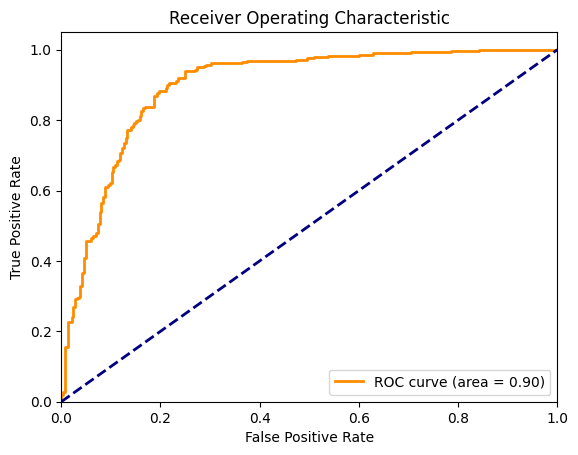

NameError: name 'pred_probs' is not defined

[0.         0.         0.         0.00350877 0.00350877 0.00701754
 0.00701754 0.01403509 0.01403509 0.02105263 0.02105263 0.0245614
 0.0245614  0.02807018 0.02807018 0.03157895 0.03157895 0.03508772
 0.03508772 0.03859649 0.03859649 0.04210526 0.04210526 0.04561404
 0.04561404 0.04912281 0.04912281 0.05964912 0.05964912 0.06315789
 0.06315789 0.07017544 0.07017544 0.07368421 0.07368421 0.07719298
 0.07719298 0.08070175 0.08070175 0.08421053 0.08421053 0.0877193
 0.0877193  0.09473684 0.09473684 0.09824561 0.09824561 0.10175439
 0.10175439 0.10526316 0.10526316 0.10877193 0.10877193 0.1122807
 0.1122807  0.11578947 0.11578947 0.11929825 0.11929825 0.12280702
 0.12280702 0.12631579 0.12631579 0.12982456 0.12982456 0.13333333
 0.13333333 0.14035088 0.14035088 0.14385965 0.14385965 0.14736842
 0.14736842 0.15087719 0.15087719 0.15438596 0.15438596 0.15789474
 0.15789474 0.16140351 0.16140351 0.16491228 0.16491228 0.16842105
 0.16842105 0.18596491 0.18596491 0.19298246 0.19298246 0.1964912

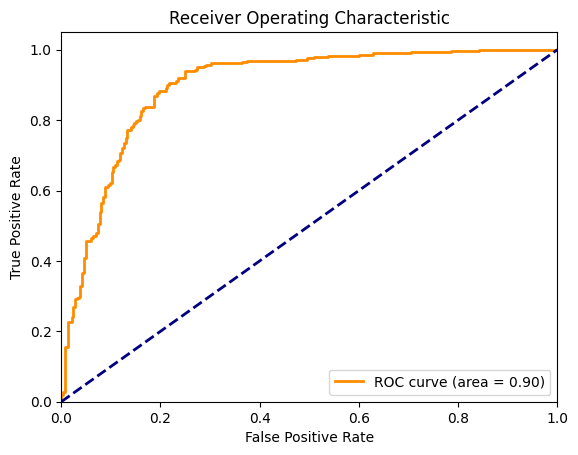

In [ ]:
# Import necessary libraries
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr, tpr, thresholds= roc_curve(y_test, pred_probs)
print(fpr,tpr)
roc_auc = auc(fpr, tpr)
J = tpr - fpr
# Find the optimal threshold
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold: ", optimal_threshold)
# Plot the ROC curve
import matplotlib.pyplot as plt

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/Semester 10/MS Dataset/My Models/ResNet.h5", compile=False)
model.summary()


Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 320, 320,  │        160 │ input_2[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 320, 320,  │      2,320 │ activation_9[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 320, 320,  │      2,320 │ activation_10[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 320, 320,  │          0 │ activation_9[0][… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 320, 320,  │          0 │ add_4[0][0]       │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 160, 160,  │      4,640 │ activation_11[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 160, 160,  │      9,248 │ activation_12[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 160, 160,  │        544 │ activation_11[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_16[0][0] 

 Total params: 308,641 (1.18 MB)

 Trainable params: 307,649 (1.17 MB)

 Non-trainable params: 992 (3.88 KB)

In [ ]:
# Save as modern .keras (works well going forward)
model.save("/content/drive/MyDrive/Semester 10/MS Dataset/My Models/ResNet.keras")

In [30]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('/content/drive/My Drive/Semester 10/MS Dataset/My Models/ResNet.keras')

# Print model summary
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 320, 320,  │        160 │ input_2[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 320, 320,  │      2,320 │ activation_9[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 320, 320,  │      2,320 │ activation_10[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │         64 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 320, 320,  │          0 │ activation_9[0][… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 320, 320,  │          0 │ add_4[0][0]       │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 160, 160,  │      4,640 │ activation_11[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 160, 160,  │      9,248 │ activation_12[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 160, 160,  │        544 │ activation_11[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_16[0][0] 

 Total params: 308,641 (1.18 MB)

 Trainable params: 307,649 (1.17 MB)

 Non-trainable params: 992 (3.88 KB)

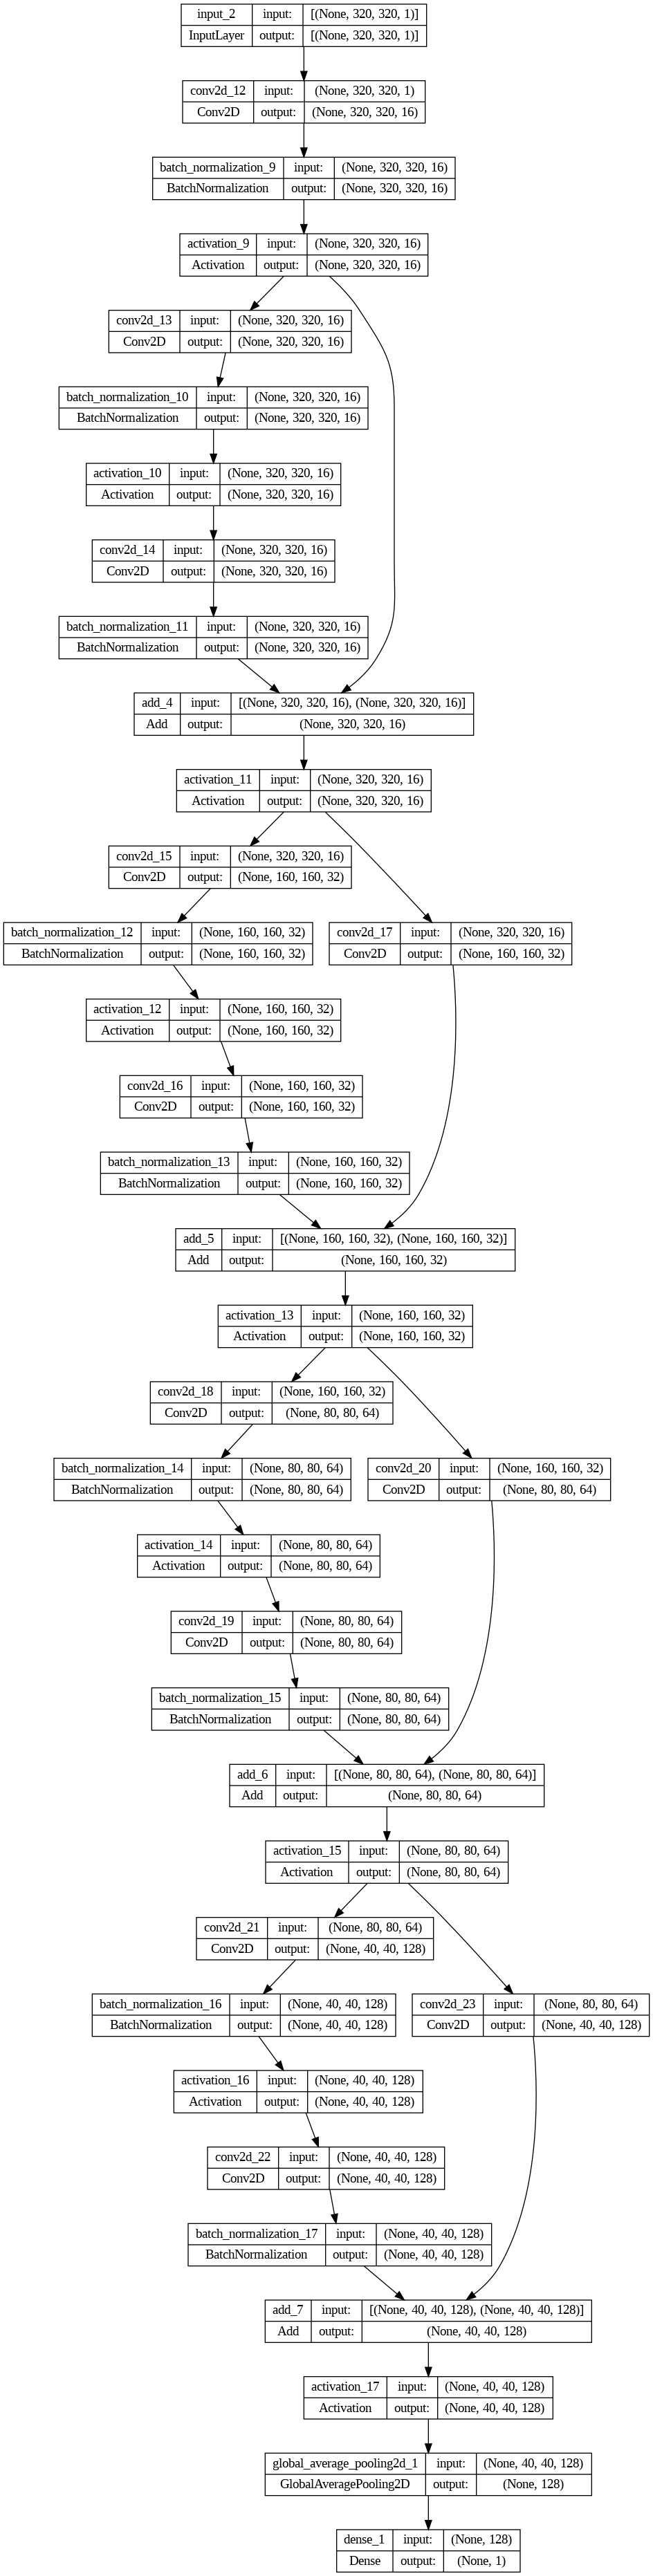

In [ ]:
from tensorflow.keras.utils import plot_model

# Assuming `model` is your AlexNet model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


In [31]:
def visualize_predictions(X, y, preds, num_samples=20):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 5))
    for i in range(num_samples):
        axes[i, 0].imshow(X[i, :, :, 0], cmap='gray')
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(X[i, :, :, 0], cmap='gray')  # Re-displaying the same image for layout consistency
        axes[i, 1].set_title('True Label: {}'.format('MS' if y[i] else 'No MS'))
        axes[i, 1].axis('off')

        axes[i, 2].imshow(X[i, :, :, 0], cmap='gray')  # Re-displaying the same image for layout consistency
        axes[i, 2].set_title('Predicted: {:.2f}% MS'.format(preds[i][0] * 100))
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()

# Predict probabilities
pred_probs = model.predict(X_test)
visualize_predictions(X_test, y_test, pred_probs)


Output hidden; open in https://colab.research.google.com to view.

In [32]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def _as_tensor_output(preds, output_index=0):
    """If model returns [out1, out2, ...], pick one. Otherwise return preds."""
    if isinstance(preds, (list, tuple)):
        return preds[output_index]
    return preds

def _find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found. Specify last_conv_layer_name manually.")

def make_gradcam_heatmap(model, img_batch, class_index=None, last_conv_layer_name=None, output_index=0):
    """
    img_batch: (1,H,W,C)
    class_index: which class to explain (None -> auto)
    output_index: if model has multiple outputs, choose which one
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = _find_last_conv_layer(model)

    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Build grad model that returns: conv features + chosen output
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, raw_preds = grad_model(img_batch, training=False)
        preds = _as_tensor_output(raw_preds, output_index=output_index)

        # preds should now be a Tensor
        preds = tf.convert_to_tensor(preds)

        # Decide which class score to use
        if preds.shape.rank == 2 and preds.shape[-1] > 1:
            # softmax / multi-class
            if class_index is None:
                class_index = int(tf.argmax(preds[0]).numpy())
            class_score = preds[:, class_index]
        else:
            # binary sigmoid or scalar output
            # Explain the single output neuron
            class_index = 0
            class_score = tf.reshape(preds, (-1,))  # shape (batch,)

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), class_index, last_conv_layer_name

def show_gradcam(model, X, y=None, idx=0, class_index=None, last_conv_layer_name=None, output_index=0, alpha=0.35):
    img = X[idx] if X.ndim == 4 else X
    img_batch = np.expand_dims(img.astype(np.float32), axis=0)

    # Get preds in a safe way for display too
    raw_preds = model.predict(img_batch, verbose=0)
    preds = _as_tensor_output(raw_preds, output_index=output_index)
    preds = np.array(preds)

    # Compute heatmap
    heatmap, used_class, used_layer = make_gradcam_heatmap(
        model,
        img_batch,
        class_index=class_index,
        last_conv_layer_name=last_conv_layer_name,
        output_index=output_index
    )

    # Resize heatmap to input size
    heatmap_tf = tf.image.resize(heatmap[..., None], (img.shape[0], img.shape[1])).numpy().squeeze()

    # Base image (grayscale)
    base = img[:, :, 0] if img.shape[-1] == 1 else img.mean(axis=-1)
    base = (base - base.min()) / (base.max() - base.min() + 1e-8)

    # Compute a nice prediction string
    if preds.ndim == 2 and preds.shape[-1] > 1:
        pred_idx = int(np.argmax(preds[0]))
        pred_str = f"class {pred_idx} prob {preds[0, pred_idx]*100:.2f}%"
    else:
        p = float(preds.reshape(-1)[0])
        pred_str = f"MS prob {p*100:.2f}%"

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(base, cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_tf, cmap="jet")
    plt.title(f"Grad-CAM\n(layer: {used_layer})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(base, cmap="gray")
    plt.imshow(heatmap_tf, cmap="jet", alpha=alpha)
    title = f"Overlay | {pred_str}"
    if y is not None and X.ndim == 4:
        true_txt = "MS" if bool(y[idx]) else "No MS"
        title += f"\nTrue: {true_txt}"
    plt.title(title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- quick debugging helper: see if your model has multiple outputs ---
print("Model outputs:", model.output)
import numpy as np

def show_random_gradcam_samples(
    model,
    X,
    y=None,
    n_samples=20,
    class_index=None,
    last_conv_layer_name=None,
    output_index=0,
    alpha=0.35,
    seed=42
):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=n_samples, replace=False)

    print("Showing Grad-CAM for indices:", idxs.tolist())
    for idx in idxs:
        show_gradcam(
            model,
            X,
            y=y,
            idx=idx,
            class_index=class_index,
            last_conv_layer_name=last_conv_layer_name,
            output_index=output_index,
            alpha=alpha
        )

# --- usage ---
show_random_gradcam_samples(
    model,
    X_test,
    y=y_test,
    n_samples=18,
    alpha=0.35
)



Output hidden; open in https://colab.research.google.com to view.

In [33]:
import numpy as np

def extract_ms_probs(model, X, output_index=0, ms_class_index=0):
    """
    Returns ms_probs shape (N,) in [0,1].
    Handles:
      - sigmoid output: (N,1) or (N,)
      - softmax output: (N,2+) -> uses ms_class_index
      - multi-output models: picks output_index
    """
    raw = model.predict(X, verbose=0)

    # If multiple outputs, pick one
    if isinstance(raw, (list, tuple)):
        raw = raw[output_index]

    raw = np.array(raw)

    # Sigmoid binary
    if raw.ndim == 1:
        ms_probs = raw
    elif raw.ndim == 2 and raw.shape[1] == 1:
        ms_probs = raw[:, 0]
    else:
        # Softmax / multi-class
        ms_probs = raw[:, ms_class_index]

    return ms_probs.astype(np.float64)

def show_sets_gradcam(
    model,
    X_test,
    y_test,
    k=5,
    output_index=0,
    ms_class_index=0,
    alpha=0.35,
    last_conv_layer_name=None
):
    ms_probs = extract_ms_probs(model, X_test, output_index=output_index, ms_class_index=ms_class_index)
    N = len(ms_probs)

    # Indices
    top_idx = np.argsort(-ms_probs)[:k]
    low_idx = np.argsort(ms_probs)[:k]
    unc_idx = np.argsort(np.abs(ms_probs - 0.5))[:k]

    def _print_group(name, idxs):
        print(f"\n{name}")
        for rank, idx in enumerate(idxs, 1):
            true_txt = "MS" if bool(y_test[idx]) else "No MS"
            print(f"  {rank:>2}. idx={idx:>5} | p(MS)={ms_probs[idx]:.4f} | true={true_txt}")

    _print_group(f"Top {k} highest p(MS)", top_idx)
    _print_group(f"Top {k} lowest p(MS)", low_idx)
    _print_group(f"Top {k} most uncertain |p-0.5| smallest", unc_idx)

    # Visualize with Grad-CAM
    groups = [
        (f"Top {k} highest p(MS)", top_idx),
        (f"Top {k} lowest p(MS)", low_idx),
        (f"Top {k} most uncertain (closest to 50%)", unc_idx),
    ]

    for title, idxs in groups:
        print("\n" + "="*80)
        print(title)
        print("="*80)
        for idx in idxs:
            # We force class_index=None because for sigmoid it’s irrelevant;
            # for softmax you *can* set class_index=ms_class_index if you want explanation specifically for MS.
            show_gradcam(
                model,
                X_test,
                y=y_test,
                idx=int(idx),
                class_index=ms_class_index,          # explain "MS class" for softmax; harmless for sigmoid
                last_conv_layer_name=last_conv_layer_name,
                output_index=output_index,
                alpha=alpha
            )

# --- run ---
show_sets_gradcam(
    model,
    X_test,
    y_test,
    k=10,
    output_index=0,       # change if your model has multiple outputs and MS probs are not output 0
    ms_class_index=0,     # if softmax, set which column corresponds to "MS"
    alpha=0.35
)


Output hidden; open in https://colab.research.google.com to view.

Expected Calibration Error (ECE): 0.0740


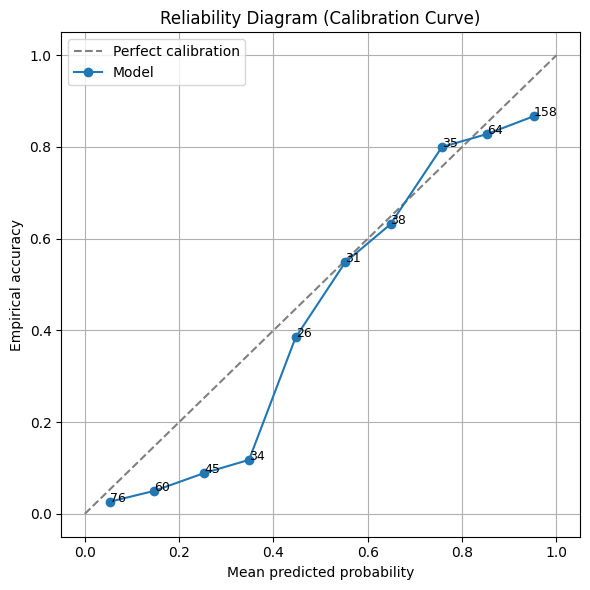

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def compute_calibration(probs, labels, n_bins=10):
    """
    probs: predicted probabilities for positive class (MS), shape (N,)
    labels: true labels {0,1}, shape (N,)
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1

    bin_acc = []
    bin_conf = []
    bin_counts = []

    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = np.mean(labels[mask])
            conf = np.mean(probs[mask])
            count = np.sum(mask)
        else:
            acc = np.nan
            conf = np.nan
            count = 0

        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_counts.append(count)

    # Expected Calibration Error (ECE)
    N = len(probs)
    ece = np.nansum([
        (bin_counts[i] / N) * abs(bin_acc[i] - bin_conf[i])
        for i in range(n_bins)
    ])

    return np.array(bin_conf), np.array(bin_acc), np.array(bin_counts), ece


# --- get probabilities ---
ms_probs = extract_ms_probs(model, X_test)   # from previous cell
y_true = y_test.astype(int)

# --- compute calibration ---
bin_conf, bin_acc, bin_counts, ece = compute_calibration(ms_probs, y_true, n_bins=10)

print(f"Expected Calibration Error (ECE): {ece:.4f}")

# --- plot reliability diagram ---
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.plot(bin_conf, bin_acc, "o-", label="Model")

for i in range(len(bin_conf)):
    if not np.isnan(bin_conf[i]):
        plt.text(bin_conf[i], bin_acc[i], f"{bin_counts[i]}", fontsize=9)

plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical accuracy")
plt.title("Reliability Diagram (Calibration Curve)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


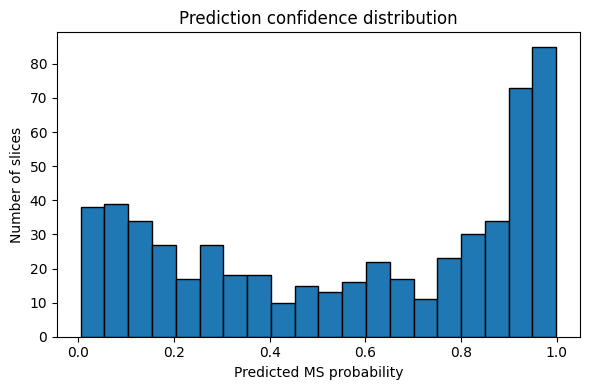

In [35]:
plt.figure(figsize=(6, 4))
plt.hist(ms_probs, bins=20, edgecolor="black")
plt.xlabel("Predicted MS probability")
plt.ylabel("Number of slices")
plt.title("Prediction confidence distribution")
plt.tight_layout()
plt.show()


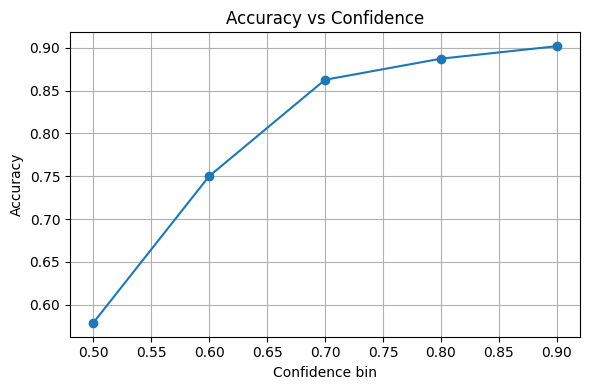

In [36]:
confidence = np.maximum(ms_probs, 1 - ms_probs)
correct = (ms_probs > 0.5) == y_true

bins = np.linspace(0.5, 1.0, 6)
bin_ids = np.digitize(confidence, bins) - 1

accs = []
counts = []

for i in range(len(bins) - 1):
    mask = bin_ids == i
    if np.any(mask):
        accs.append(np.mean(correct[mask]))
        counts.append(np.sum(mask))
    else:
        accs.append(np.nan)
        counts.append(0)

plt.figure(figsize=(6, 4))
plt.plot(bins[:-1], accs, "o-")
plt.xlabel("Confidence bin")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Confidence")
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import matplotlib.pyplot as plt

def confusion_by_confidence(probs, labels, bins=[0, 0.5, 0.75, 0.9, 1.0]):
    preds = (probs >= 0.5).astype(int)
    correct = preds == labels

    stats = []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i+1]
        mask = (probs >= lo) & (probs < hi)

        if np.sum(mask) == 0:
            stats.append((0, 0, 0, 0))
            continue

        tp = np.sum((preds == 1) & (labels == 1) & mask)
        fp = np.sum((preds == 1) & (labels == 0) & mask)
        tn = np.sum((preds == 0) & (labels == 0) & mask)
        fn = np.sum((preds == 0) & (labels == 1) & mask)

        stats.append((tp, fp, tn, fn))

    return stats

bins = [0, 0.5, 0.75, 0.9, 1.0]
stats = confusion_by_confidence(ms_probs, y_true, bins)

for i, (tp, fp, tn, fn) in enumerate(stats):
    print(f"P in [{bins[i]:.2f},{bins[i+1]:.2f}): TP={tp}, FP={fp}, TN={tn}, FN={fn}")


P in [0.00,0.50): TP=0, FP=0, TN=218, FN=23
P in [0.50,0.75): TP=51, FP=30, TN=0, FN=0
P in [0.75,0.90): TP=71, FP=16, TN=0, FN=0
P in [0.90,1.00): TP=137, FP=21, TN=0, FN=0


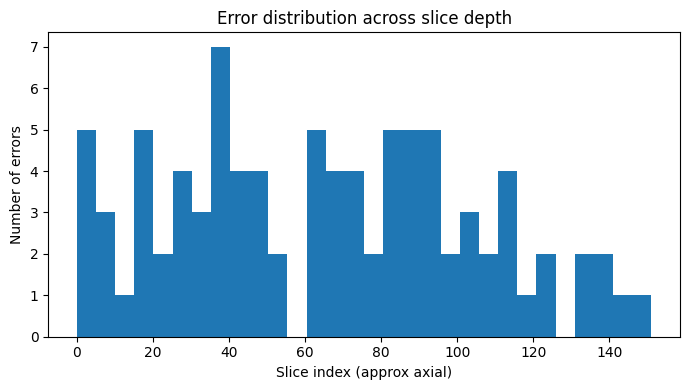

In [38]:
 slice_indices = np.arange(len(y_true)) % 155  # adjust if slices per volume differ
errors = (ms_probs >= 0.5) != y_true

plt.figure(figsize=(7,4))
plt.hist(slice_indices[errors], bins=30)
plt.xlabel("Slice index (approx axial)")
plt.ylabel("Number of errors")
plt.title("Error distribution across slice depth")
plt.tight_layout()
plt.show()


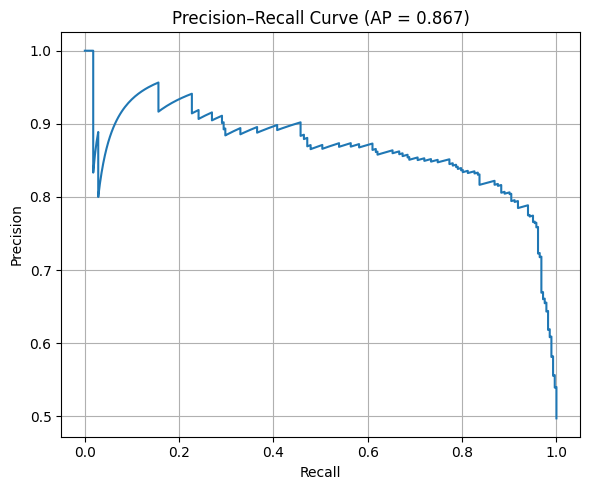

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, ms_probs)
ap = average_precision_score(y_true, ms_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {ap:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()


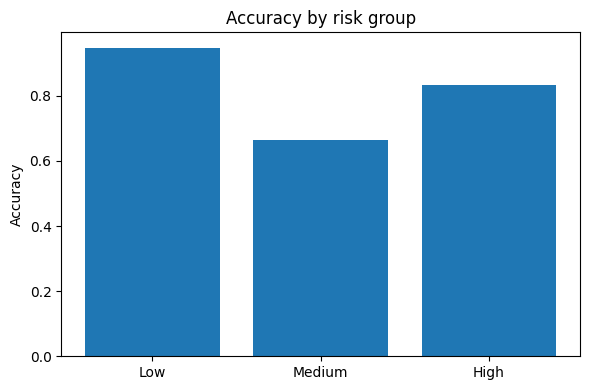

Counts: {'Low': np.int64(191), 'Medium': np.int64(104), 'High': np.int64(272)}


In [40]:
bins = [0, 0.33, 0.66, 1.0]
labels = ["Low", "Medium", "High"]

risk_bins = np.digitize(ms_probs, bins) - 1

acc = []
counts = []

for i in range(3):
    mask = risk_bins == i
    if np.sum(mask) > 0:
        acc.append(np.mean((ms_probs[mask] >= 0.5) == y_true[mask]))
        counts.append(np.sum(mask))
    else:
        acc.append(np.nan)
        counts.append(0)

plt.figure(figsize=(6,4))
plt.bar(labels, acc)
plt.ylabel("Accuracy")
plt.title("Accuracy by risk group")
plt.tight_layout()
plt.show()

print("Counts:", dict(zip(labels, counts)))


In [41]:
import numpy as np

def bin_report(probs, y_true, bins=(0, 0.33, 0.66, 1.0), threshold=0.5):
    probs = np.asarray(probs).reshape(-1)
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_pred = (probs >= threshold).astype(int)

    rows = []
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        m = (probs >= lo) & (probs < hi) if i < len(bins)-2 else (probs >= lo) & (probs <= hi)

        n = int(m.sum())
        if n == 0:
            rows.append((f"[{lo:.2f},{hi:.2f}]", 0, np.nan, np.nan, np.nan, np.nan, np.nan))
            continue

        yt = y_true[m]; yp = y_pred[m]; pr = probs[m]
        tp = int(((yp==1) & (yt==1)).sum())
        fp = int(((yp==1) & (yt==0)).sum())
        tn = int(((yp==0) & (yt==0)).sum())
        fn = int(((yp==0) & (yt==1)).sum())

        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall    = tp / (tp + fn) if (tp + fn) else np.nan
        acc       = (tp + tn) / n
        prevalence = yt.mean()
        mean_p    = pr.mean()

        rows.append((f"[{lo:.2f},{hi:.2f}]", n, mean_p, prevalence, acc, precision, recall))

    print("Bin       |  N | mean p | true MS rate | accuracy | precision | recall")
    print("-"*74)
    for r in rows:
        b,n,mp,prev,acc,prec,rec = r
        print(f"{b:9s} | {n:3d} | {mp:6.3f} | {prev:11.3f} | {acc:8.3f} | {prec:9.3f} | {rec:6.3f}")

# run
bin_report(ms_probs, y_true, bins=(0,0.33,0.66,1.0), threshold=0.5)


Bin       |  N | mean p | true MS rate | accuracy | precision | recall
--------------------------------------------------------------------------
[0.00,0.33] | 191 |  0.143 |       0.052 |    0.948 |       nan |  0.000
[0.33,0.66] | 104 |  0.499 |       0.433 |    0.663 |     0.593 |  0.711
[0.66,1.00] | 272 |  0.889 |       0.835 |    0.835 |     0.835 |  1.000


In [43]:
# --- Install deps if missing ---
!pip -q install pydicom pillow

import os, glob
import numpy as np
import pydicom
from PIL import Image
import matplotlib.pyplot as plt

from skimage.transform import resize
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# =========================
# 0) CONFIG
# =========================
NEW_DIR = "/content/drive/My Drive/Semester 10/MS Dataset/MS Conv Network /New Data/DICOM/ST000000/"  # <-- change if needed
TARGET_HW = (320, 320)  # must match your model input
MASK_SUFFIX = "BM.png"  # screenshot suggests this pattern

assert os.path.isdir(NEW_DIR), f"Folder not found: {NEW_DIR}"
assert "preprocess_data" in globals(), "preprocess_data(...) not found. Re-run the cell where you defined it."

# =========================
# 1) IO helpers
# =========================
def load_dicom_2d(path: str) -> np.ndarray:
    """Load a single 2D DICOM and return float32 image."""
    ds = pydicom.dcmread(path, force=True)
    img = ds.pixel_array.astype(np.float32)

    # Apply rescale slope/intercept if present
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    # Handle MONOCHROME1 inversion
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    return img

def load_mask_png(path: str) -> np.ndarray:
    """Load a PNG mask -> binary float32 {0,1}."""
    m = Image.open(path).convert("L")
    m = np.array(m, dtype=np.float32)
    # robust binarization
    m = (m > 0).astype(np.float32)
    return m

def preprocess_mask_like_training(mask_2d: np.ndarray) -> np.ndarray:
    """
    We don't have your exact geometric transforms from preprocess_data,
    but in your compile_data you applied preprocess_data() only to images.
    Most pipelines here are: resize -> normalize. So we resize masks similarly
    (nearest-neighbor), and keep them binary.
    """
    m = resize(mask_2d, TARGET_HW, order=0, preserve_range=True, anti_aliasing=False).astype(np.float32)
    m = (m > 0.5).astype(np.float32)
    return m

def preprocess_image_like_training(img_2d: np.ndarray) -> np.ndarray:
    """Use your preprocess_data exactly, then ensure shape (H,W,1)."""
    x = preprocess_data(img_2d)  # <-- your function
    x = np.asarray(x)

    # Common outcomes:
    # - (320,320) -> add channel
    # - (320,320,1) -> ok
    if x.ndim == 2:
        x = x[..., None]
    if x.shape[:2] != TARGET_HW:
        # safety: if preprocess_data didn't resize, enforce it (but ideally it already did)
        x2 = resize(x[...,0], TARGET_HW, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)
        x = x2[..., None]
    return x.astype(np.float32)

# =========================
# 2) Discover samples (DICOM + mask)
# =========================
def is_probably_dicom(path: str) -> bool:
    # quick heuristic: DICOM often has no extension or .dcm; skip png/jpg etc.
    low = path.lower()
    if low.endswith((".png", ".jpg", ".jpeg", ".npy", ".nii", ".nii.gz")):
        return False
    # Try reading header lightly
    try:
        _ = pydicom.dcmread(path, stop_before_pixels=True, force=True)
        return True
    except Exception:
        return False

all_files = sorted([os.path.join(NEW_DIR, f) for f in os.listdir(NEW_DIR)])
dicom_files = [f for f in all_files if is_probably_dicom(f)]

print(f"Found {len(dicom_files)} DICOM files in: {NEW_DIR}")

samples = []
missing_masks = 0

for dcm_path in dicom_files:
    base = os.path.basename(dcm_path)
    mask_path = os.path.join(NEW_DIR, base + MASK_SUFFIX)  # e.g. MR000032 + BM.png

    if not os.path.isfile(mask_path):
        missing_masks += 1
        continue

    samples.append((dcm_path, mask_path))

print(f"Paired samples with masks: {len(samples)}")
print(f"DICOMs missing masks (skipped): {missing_masks}")

assert len(samples) > 0, "No DICOM+mask pairs found. Check naming/pattern."

# =========================
# 3) Build X_new, masks_new, y_new (from mask presence)
# =========================
X_new = []
M_new = []
y_new = []
names = []

for dcm_path, mask_path in samples:
    img = load_dicom_2d(dcm_path)
    msk = load_mask_png(mask_path)

    x = preprocess_image_like_training(img)               # (320,320,1)
    m = preprocess_mask_like_training(msk)                # (320,320)

    label = 1 if np.max(m) > 0 else 0                     # slice-level MS presence

    X_new.append(x)
    M_new.append(m)
    y_new.append(label)
    names.append(os.path.basename(dcm_path))

X_new = np.stack(X_new, axis=0)  # (N,320,320,1)
M_new = np.stack(M_new, axis=0)  # (N,320,320)
y_new = np.asarray(y_new).astype(int)

print("X_new:", X_new.shape, "M_new:", M_new.shape, "y_new:", y_new.shape)
print("MS prevalence:", y_new.mean())

# =========================
# 4) Predict MS probabilities robustly (handles named inputs)
# =========================
def predict_ms_probs(model, X):
    # avoid Keras input-structure warning for named input models
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        X_in = {model.input_names[0]: X}
        p = model.predict(X_in, verbose=0)
    else:
        p = model.predict(X, verbose=0)

    # handle list outputs
    if isinstance(p, (list, tuple)):
        p = p[0]

    p = np.asarray(p)
    if p.ndim == 2 and p.shape[1] == 1:
        return p[:, 0]
    if p.ndim == 1:
        return p
    # if logits with 2 classes
    if p.ndim == 2 and p.shape[1] == 2:
        return p[:, 1]
    raise ValueError(f"Unexpected prediction shape: {p.shape}")

ms_probs_new = predict_ms_probs(model, X_new)
y_pred_new = (ms_probs_new >= 0.5).astype(int)

print("\n=== NEW DATASET PERFORMANCE (threshold=0.5) ===")
print("Accuracy :", accuracy_score(y_new, y_pred_new))
print("Precision:", precision_score(y_new, y_pred_new, zero_division=0))
print("Recall   :", recall_score(y_new, y_pred_new, zero_division=0))
print("F1       :", f1_score(y_new, y_pred_new, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_new, y_pred_new))

# =========================
# 5) Grad-CAM + mask comparison
# =========================
import tensorflow as tf

def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        try:
            out_shape = layer.output_shape
        except Exception:
            continue
        # conv feature maps typically rank-4: (B,H,W,C)
        if isinstance(out_shape, tuple) and len(out_shape) == 4:
            if "conv" in layer.name.lower():
                return layer.name
    # fallback: last rank-4 layer
    for layer in reversed(model.layers):
        try:
            out_shape = layer.output_shape
        except Exception:
            continue
        if isinstance(out_shape, tuple) and len(out_shape) == 4:
            return layer.name
    raise ValueError("No rank-4 (conv-like) layer found for Grad-CAM.")

LAST_CONV = find_last_conv_layer_name(model)
print("\nUsing last conv layer for Grad-CAM:", LAST_CONV)

def make_gradcam_heatmap(model, img_batch, last_conv_layer_name, class_index=0):
    """
    img_batch: (B,H,W,1)
    Returns heatmap (H,W) in [0,1]
    """
    # Build a model that maps input -> (conv_output, preds)
    conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.Model([model.inputs], [conv_layer.output, model.output])

    # Feed named input if needed
    inputs = img_batch
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        inputs = {model.input_names[0]: img_batch}

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(inputs, training=False)

        # handle list preds
        if isinstance(preds, (list, tuple)):
            preds = preds[0]

        preds = tf.convert_to_tensor(preds)
        if preds.shape.rank == 2 and preds.shape[1] == 1:
            class_score = preds[:, 0]
        elif preds.shape.rank == 2 and preds.shape[1] == 2:
            class_score = preds[:, 1]  # MS probability/logit
        else:
            class_score = preds[:, class_index]

    grads = tape.gradient(class_score, conv_out)               # (B,h,w,c)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))          # (B,c)

    conv_out = conv_out[0]                                     # (h,w,c)
    pooled_grads = pooled_grads[0]                             # (c,)
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)  # (h,w)

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    # upsample to input size
    heatmap = resize(heatmap, TARGET_HW, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)
    heatmap = np.clip(heatmap, 0, 1)
    return heatmap

def dice_coeff(a, b, eps=1e-8):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    return (2*inter + eps) / (a.sum() + b.sum() + eps)

def pointing_game_hit(heatmap, mask):
    yx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    return bool(mask[yx] > 0)

def evaluate_localization(model, X, M, last_conv_layer_name, heat_thr=0.6):
    dices = []
    hits = []
    for i in range(X.shape[0]):
        hm = make_gradcam_heatmap(model, X[i:i+1], last_conv_layer_name)
        pred_region = (hm >= heat_thr).astype(np.float32)
        dices.append(dice_coeff(pred_region, M[i] > 0.5))
        hits.append(pointing_game_hit(hm, M[i]))
    return np.array(dices), np.array(hits)

dices_new, hits_new = evaluate_localization(model, X_new, M_new, LAST_CONV, heat_thr=0.6)
print("\n=== Grad-CAM vs Mask (localization proxies) ===")
print("Pointing-game hit-rate:", hits_new.mean())
print("Dice@heat>=0.6 (mean):", np.nanmean(dices_new))
print("Dice@heat>=0.6 (median):", np.nanmedian(dices_new))

# =========================
# 6) Visualize: best/worst overlap + some examples
# =========================
def show_examples(indices, alpha=0.35):
    n = len(indices)
    fig, axes = plt.subplots(n, 4, figsize=(18, 4*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, idx in enumerate(indices):
        x = X_new[idx, :, :, 0]
        m = M_new[idx]
        p = ms_probs_new[idx]
        y = y_new[idx]

        hm = make_gradcam_heatmap(model, X_new[idx:idx+1], LAST_CONV)

        # 1) input
        axes[r,0].imshow(x, cmap="gray")
        axes[r,0].set_title(f"{names[idx]}\nInput")
        axes[r,0].axis("off")

        # 2) mask
        axes[r,1].imshow(x, cmap="gray")
        axes[r,1].imshow(m, alpha=0.35)  # mask overlay
        axes[r,1].set_title("GT mask overlay")
        axes[r,1].axis("off")

        # 3) heatmap
        axes[r,2].imshow(hm, cmap="jet", vmin=0, vmax=1)
        axes[r,2].set_title(f"Grad-CAM ({LAST_CONV})")
        axes[r,2].axis("off")

        # 4) overlay + mask contour-ish
        axes[r,3].imshow(x, cmap="gray")
        axes[r,3].imshow(hm, cmap="jet", alpha=alpha, vmin=0, vmax=1)
        axes[r,3].imshow(m, alpha=0.20)  # also overlay mask
        axes[r,3].set_title(f"Overlay | p(MS)={p*100:.1f}% | True={'MS' if y else 'No-MS'}\nDice@0.6={dices_new[idx]:.3f} | Hit={hits_new[idx]}")
        axes[r,3].axis("off")

    plt.tight_layout()
    plt.show()

# Show: 3 best dice + 3 worst dice (among true MS slices), plus 3 high-conf false positives if any
ms_idx = np.where(y_new == 1)[0]
nonms_idx = np.where(y_new == 0)[0]

best_ms = ms_idx[np.argsort(-dices_new[ms_idx])][:3] if len(ms_idx) else []
worst_ms = ms_idx[np.argsort(dices_new[ms_idx])][:3] if len(ms_idx) else []

fp_idx = np.where((y_new == 0) & (ms_probs_new >= 0.9))[0]
fp_show = fp_idx[:3]

print("\nBest MS (by Dice):", best_ms)
print("Worst MS (by Dice):", worst_ms)
print("High-conf false positives (p>=0.9):", fp_show)

to_show = list(best_ms) + list(worst_ms) + list(fp_show)
to_show = list(dict.fromkeys(to_show))  # unique, keep order

if len(to_show) == 0:
    print("Nothing to show (no MS slices or no matching indices).")
else:
    show_examples(to_show, alpha=0.35)


/usr/local/lib/python3.12/dist-packages/pydicom/filereader.py:402: UserWarning: Expected implicit VR, but found explicit VR - using explicit VR for reading
  warn_and_log(f"{msg} - using {found_vr} VR for reading", UserWarning)


Found 13 DICOM files in: /content/drive/My Drive/Semester 10/MS Dataset/MS Conv Network /New Data/DICOM/ST000000/
Paired samples with masks: 5
DICOMs missing masks (skipped): 8
X_new: (5, 320, 320, 1) M_new: (5, 320, 320) y_new: (5,)
MS prevalence: 1.0

=== NEW DATASET PERFORMANCE (threshold=0.5) ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1       : 1.0
Confusion matrix:
 [[5]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


ValueError: No rank-4 (conv-like) layer found for Grad-CAM.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize




# --- 1) Utilities: overlap metrics ---
def dice_coeff(a, b, eps=1e-8):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    return (2*inter + eps) / (a.sum() + b.sum() + eps)

def pointing_game_hit(heatmap, mask):
    yx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    return bool(mask[yx] > 0)

# --- 2) Make sure you have a function that returns the heatmap as array ---
# If your existing Grad-CAM code has make_gradcam_heatmap(...) already, use it.
# Otherwise, adapt your show_gradcam to return heatmap. Here’s a small adapter:
import numpy as np
from skimage.transform import resize

def _unwrap_heatmap(hm):
    """If make_gradcam_heatmap returns (heatmap, ...), keep only the heatmap."""
    if isinstance(hm, (tuple, list)):
        return hm[0]
    return hm

def get_gradcam_heatmap_from_existing(
    model, img_batch, last_conv_layer_name, ms_class_index=0, output_index=0
):
    """
    Calls YOUR existing make_gradcam_heatmap(...) and returns only the heatmap array.
    Also feeds named input if model expects it.
    """
    # Feed as dict if model has named input (removes warning)
    inputs = img_batch
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        inputs = {model.input_names[0]: img_batch}

    hm = make_gradcam_heatmap(
        model,
        inputs,  # <-- dict or tensor
        class_index=ms_class_index,
        last_conv_layer_name=last_conv_layer_name,
        output_index=output_index
    )
    hm = _unwrap_heatmap(hm)
    hm = np.asarray(hm, dtype=np.float32)
    return hm


# --- 3) Visualize a list of indices with mask + gradcam ---
def show_mask_gradcam_set(
    model,
    X,
    y,
    masks,
    indices,
    last_conv_layer_name,
    ms_class_index=0,
    output_index=0,
    alpha=0.35,
    heat_thr=0.6
):
    ms_probs = extract_ms_probs(model, X, output_index=output_index, ms_class_index=ms_class_index)

    fig, axes = plt.subplots(len(indices), 4, figsize=(18, 4*len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    dices = []
    hits = []

    for r, idx in enumerate(indices):
        x = X[idx, :, :, 0]
        m = masks[idx]
        true_txt = "MS" if bool(y[idx]) else "No MS"
        p = ms_probs[idx]

        hm = get_gradcam_heatmap_from_existing(
            model, X[idx:idx+1], last_conv_layer_name,
            ms_class_index=ms_class_index, output_index=output_index
        )

        # Ensure same size
        if hm.shape != m.shape:
            hm = resize(hm, m.shape, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)

        pred_region = (hm >= heat_thr)
        d = dice_coeff(pred_region, m > 0.5)
        h = pointing_game_hit(hm, m)

        dices.append(d); hits.append(h)

        # 1) Input
        axes[r, 0].imshow(x, cmap="gray")
        axes[r, 0].set_title(f"Input | idx={idx}")
        axes[r, 0].axis("off")

        # 2) GT mask overlay
        axes[r, 1].imshow(x, cmap="gray")
        axes[r, 1].imshow(m, alpha=0.35)
        axes[r, 1].set_title("GT mask overlay")
        axes[r, 1].axis("off")

        # 3) Grad-CAM
        axes[r, 2].imshow(hm, cmap="jet", vmin=0, vmax=1)
        axes[r, 2].set_title(f"Grad-CAM ({last_conv_layer_name})")
        axes[r, 2].axis("off")

        # 4) Overlay: heat + mask
        axes[r, 3].imshow(x, cmap="gray")
        axes[r, 3].imshow(hm, cmap="jet", alpha=alpha, vmin=0, vmax=1)
        axes[r, 3].imshow(m, alpha=0.20)
        axes[r, 3].set_title(
            f"Overlay | p(MS)={p*100:.1f}% | True={true_txt}\nDice@{heat_thr}={d:.3f} | Hit={h}"
        )
        axes[r, 3].axis("off")

    plt.tight_layout()
    plt.show()

    dices = np.array(dices)
    hits = np.array(hits, dtype=np.float32)
    print(f"Mean Dice@{heat_thr}: {dices.mean():.3f}  | Median: {np.median(dices):.3f}")
    print(f"Pointing-game hit-rate: {hits.mean():.3f}")

# --- 4) Choose index sets like before: top/low/uncertain ---
def show_sets_gradcam_with_masks(
    model,
    X,
    y,
    masks,
    k=5,
    last_conv_layer_name="conv2d_23",   # <-- use the one you know works
    output_index=0,
    ms_class_index=0,
    alpha=0.35,
):
    ms_probs = extract_ms_probs(model, X, output_index=output_index, ms_class_index=ms_class_index)

    top_idx = np.argsort(-ms_probs)[:k]
    low_idx = np.argsort(ms_probs)[:k]
    unc_idx = np.argsort(np.abs(ms_probs - 0.5))[:k]

    groups = [
        (f"Top {k} highest p(MS)", top_idx),
        (f"Top {k} lowest p(MS)", low_idx),
        (f"Top {k} most uncertain (closest to 50%)", unc_idx),
    ]

    for title, idxs in groups:
        print("\n" + "="*80)
        print(title)
        print("="*80)
        for idx in idxs:
            true_txt = "MS" if bool(y[idx]) else "No MS"
            print(f"idx={int(idx):>4} | p(MS)={ms_probs[idx]:.4f} | true={true_txt}")

        show_mask_gradcam_set(
            model, X, y, masks,
            indices=[int(i) for i in idxs],
            last_conv_layer_name=last_conv_layer_name,
            ms_class_index=ms_class_index,
            output_index=output_index,
            alpha=alpha
        )

# --- run on new dataset ---
# after you build X_new, y_new, M_new:
show_sets_gradcam_with_masks(
    model,
    X_new,
    y_new,
    M_new,
    k=5,
    last_conv_layer_name="conv2d_23",  # <-- replace if your working layer name differs
    output_index=0,
    ms_class_index=0,
    alpha=0.35
)


Output hidden; open in https://colab.research.google.com to view.

In [45]:
# If needed
!pip -q install pydicom ipywidgets

import os, re
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import tensorflow as tf
from skimage.transform import resize

from google.colab import output
output.enable_custom_widget_manager()
import ipywidgets as widgets
from IPython.display import display

# =========================
# CONFIG
# =========================
ROOT_ST = "/content/drive/My Drive/Semester 10/MS Dataset/MS Conv Network /New Data/DICOM/ST000000/"
TARGET_HW = (320, 320)
BATCH_SIZE = 32

assert os.path.isdir(ROOT_ST), f"ROOT_ST not found: {ROOT_ST}"
assert "preprocess_data" in globals(), "preprocess_data(...) not found. Re-run the cell where you defined it."
assert "model" in globals(), "model not found. Load your model first."

# =========================
# helpers
# =========================
def natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]

def list_dirs(path, prefix=None):
    dirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    if prefix:
        dirs = [d for d in dirs if d.startswith(prefix)]
    return sorted(dirs, key=natural_key)

def is_probably_dicom(path: str) -> bool:
    low = path.lower()
    if low.endswith((".png", ".jpg", ".jpeg", ".nii", ".nii.gz", ".npy")):
        return False
    try:
        pydicom.dcmread(path, stop_before_pixels=True, force=True)
        return True
    except Exception:
        return False

def view_normalize(img):
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    img = np.clip(img, lo, hi)
    return (img - lo) / (hi - lo + 1e-8)

def preprocess_image_like_training(img_2d: np.ndarray) -> np.ndarray:
    x = preprocess_data(img_2d)  # YOUR training preprocessing
    x = np.asarray(x)
    if x.ndim == 2:
        x = x[..., None]
    if x.shape[:2] != TARGET_HW:
        x0 = resize(x[..., 0], TARGET_HW, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)
        x = x0[..., None]
    return x.astype(np.float32)

def load_dicom_2d(path: str):
    ds = pydicom.dcmread(path, force=True)
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    return img, ds

def extract_ms_probs_named(model, X, output_index=0, ms_class_index=0):
    # feed dict if named input (removes the "structure of inputs" warning)
    X_in = X
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        X_in = {model.input_names[0]: X}

    raw = model.predict(X_in, verbose=0)
    if isinstance(raw, (list, tuple)):
        raw = raw[output_index]
    raw = np.asarray(raw)

    # sigmoid: (N,) or (N,1)
    if raw.ndim == 1:
        p = raw
    elif raw.ndim == 2 and raw.shape[1] == 1:
        p = raw[:, 0]
    else:
        # softmax / multi-class
        p = raw[:, ms_class_index]
    return p.astype(np.float64)

# =========================
# Grad-CAM (robust + named input)
# =========================
def iter_layers_recursive(layer):
    yield layer
    if isinstance(layer, tf.keras.Model):
        for sub in layer.layers:
            yield from iter_layers_recursive(sub)

def find_last_conv2d_name(model):
    last = None
    for layer in iter_layers_recursive(model):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last = layer.name
    if last is None:
        raise ValueError("No Conv2D layer found for Grad-CAM.")
    return last

def make_gradcam_heatmap(model, img_batch, last_conv_layer_name, output_index=0, ms_class_index=0):
    conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.Model([model.inputs], [conv_layer.output, model.output])

    inputs = img_batch
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        inputs = {model.input_names[0]: img_batch}

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(inputs, training=False)
        if isinstance(preds, (list, tuple)):
            preds = preds[output_index]
        preds = tf.convert_to_tensor(preds)

        if preds.shape.rank == 2 and preds.shape[1] == 1:
            score = preds[:, 0]
        elif preds.shape.rank == 2:
            score = preds[:, ms_class_index]
        else:
            score = preds[:, 0]

    grads = tape.gradient(score, conv_out)

    conv_out = conv_out[0]          # (h,w,c)
    grads = grads[0]                # (h,w,c)
    weights = tf.reduce_mean(grads, axis=(0, 1))  # (c,)

    cam = tf.reduce_sum(conv_out * weights, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = cam.numpy()

    cam = resize(cam, TARGET_HW, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)
    cam = np.clip(cam, 0, 1)
    return cam

# =========================
# MAIN: treat MR files as slices
# =========================
def browse_patient_slices(patient_idx=0, output_index=0, ms_class_index=0, last_conv_layer_name=None):
    se_folders = list_dirs(ROOT_ST, prefix="SE")
    if not se_folders:
        raise ValueError(f"No SE folders found under: {ROOT_ST}")
    if not (0 <= patient_idx < len(se_folders)):
        raise ValueError(f"patient_idx out of range [0..{len(se_folders)-1}]")

    se = se_folders[patient_idx]
    se_path = os.path.join(ROOT_ST, se)

    # MR are FILES (slices) in your structure
    all_files = [os.path.join(se_path, f) for f in os.listdir(se_path) if os.path.isfile(os.path.join(se_path, f))]
    mr_files = [p for p in all_files if os.path.basename(p).startswith("MR") and is_probably_dicom(p)]
    mr_files = sorted(mr_files, key=lambda p: natural_key(os.path.basename(p)))

    if not mr_files:
        # fallback: any dicom file
        mr_files = [p for p in all_files if is_probably_dicom(p)]
        mr_files = sorted(mr_files, key=lambda p: natural_key(os.path.basename(p)))

    if not mr_files:
        raise ValueError(f"No DICOM files found in: {se_path}")

    print(f"Patient idx={patient_idx} -> {se}")
    print(f"Found {len(mr_files)} MR slice-files in: {se_path}")
    print("Example:", [os.path.basename(p) for p in mr_files[:10]], "..." if len(mr_files) > 10 else "")

    # Precompute probabilities for all slices (batched)
    probs = np.zeros(len(mr_files), dtype=np.float64)
    cache_raw = [None] * len(mr_files)  # optional: keep raw slices after first load (fast slider)
    cache_x   = [None] * len(mr_files)  # optional: keep preprocessed input

    # Batch preprocessing -> predict
    batch = []
    batch_idxs = []
    for i, path in enumerate(mr_files):
        img, _ = load_dicom_2d(path)
        cache_raw[i] = img
        x = preprocess_image_like_training(img)
        cache_x[i] = x
        batch.append(x)
        batch_idxs.append(i)

        if len(batch) == BATCH_SIZE or i == len(mr_files) - 1:
            Xb = np.stack(batch, axis=0)  # (B,320,320,1)
            pb = extract_ms_probs_named(model, Xb, output_index=output_index, ms_class_index=ms_class_index)
            probs[np.array(batch_idxs)] = pb
            batch, batch_idxs = [], []

    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv2d_name(model)
    print("Grad-CAM layer:", last_conv_layer_name)

    # slider
    slider = widgets.IntSlider(value=0, min=0, max=len(mr_files)-1, step=1, description="Slice")
    out = widgets.Output()

    def render(idx):
        path = mr_files[idx]
        raw = cache_raw[idx]
        x = cache_x[idx][:, :, 0]     # (320,320)
        p = probs[idx]
        hm = make_gradcam_heatmap(model, cache_x[idx][None, ...], last_conv_layer_name,
                                  output_index=output_index, ms_class_index=ms_class_index)

        raw_v = view_normalize(raw)
        x_v = view_normalize(x)

        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(1, 4, figsize=(18, 4))

            ax[0].imshow(raw_v, cmap="gray")
            ax[0].set_title(f"RAW\n{os.path.basename(path)}\nidx={idx}/{len(mr_files)-1}")
            ax[0].axis("off")

            ax[1].imshow(x_v, cmap="gray")
            ax[1].set_title("Preprocessed (model input)")
            ax[1].axis("off")

            ax[2].imshow(hm, cmap="jet", vmin=0, vmax=1)
            ax[2].set_title("Grad-CAM")
            ax[2].axis("off")

            ax[3].imshow(x_v, cmap="gray")
            ax[3].imshow(hm, cmap="jet", alpha=0.35, vmin=0, vmax=1)
            ax[3].set_title(f"Overlay | p(MS)={p*100:.1f}%")
            ax[3].axis("off")

            plt.tight_layout()
            plt.show()

            print(f"p(MS)={p:.4f} | min/med/max across patient = {probs.min():.3f}/{np.median(probs):.3f}/{probs.max():.3f}")

    def on_change(change):
        if change["name"] == "value":
            render(change["new"])

    slider.observe(on_change)
    display(slider, out)
    render(0)

    # quick list of most suspicious slices
    top = np.argsort(-probs)[:10]
    print("\nTop 10 slices by p(MS):")
    for r, i in enumerate(top, 1):
        print(f"  {r:>2}. idx={i:>4} | p(MS)={probs[i]:.4f} | file={os.path.basename(mr_files[i])}")

# =========================
# USAGE
# =========================
# browse_patient_slices(patient_idx=1)


In [ ]:
browse_patient_slices(patient_idx=8)


In [46]:
!pip -q install pydicom ipywidgets pandas scikit-learn

import os, re, time
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
from skimage.transform import resize

from google.colab import output
output.enable_custom_widget_manager()
import ipywidgets as widgets
from IPython.display import display, clear_output

# ----------------------------
# CONFIG (edit if needed)
# ----------------------------
ROOT_ST = "/content/drive/My Drive/Semester 10/MS Dataset/MS Conv Network /New Data/DICOM/ST000000/"
SAVE_CSV = "/content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv"
TARGET_HW = (320, 320)

assert os.path.isdir(ROOT_ST), f"ROOT_ST not found: {ROOT_ST}"
assert "model" in globals(), "model not loaded."
assert "preprocess_data" in globals(), "preprocess_data(...) not defined."

# ----------------------------
# Helpers
# ----------------------------
def natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]

def is_probably_dicom(path: str) -> bool:
    low = path.lower()
    if low.endswith((".png", ".jpg", ".jpeg", ".nii", ".nii.gz", ".npy")):
        return False
    try:
        pydicom.dcmread(path, stop_before_pixels=True, force=True)
        return True
    except Exception:
        return False

def view_normalize(img):
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    img = np.clip(img, lo, hi)
    return (img - lo) / (hi - lo + 1e-8)

def load_dicom_2d(path: str):
    ds = pydicom.dcmread(path, force=True)
    img = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img
    return img, ds

def preprocess_image_like_training(img_2d: np.ndarray) -> np.ndarray:
    x = preprocess_data(img_2d)  # your pipeline
    x = np.asarray(x)
    if x.ndim == 2:
        x = x[..., None]
    if x.shape[:2] != TARGET_HW:
        x0 = resize(x[..., 0], TARGET_HW, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)
        x = x0[..., None]
    return x.astype(np.float32)

def extract_ms_prob(model, x_1hw1, output_index=0, ms_class_index=0):
    # named input support
    xin = x_1hw1
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        xin = {model.input_names[0]: x_1hw1}

    raw = model.predict(xin, verbose=0)
    if isinstance(raw, (list, tuple)):
        raw = raw[output_index]
    raw = np.asarray(raw)

    if raw.ndim == 1:
        p = float(raw[0])
    elif raw.ndim == 2 and raw.shape[1] == 1:
        p = float(raw[0, 0])
    else:
        p = float(raw[0, ms_class_index])
    return p

# ----------------------------
# Build list of slice files
# ----------------------------
se_folders = sorted([d for d in os.listdir(ROOT_ST) if os.path.isdir(os.path.join(ROOT_ST, d)) and d.startswith("SE")],
                    key=natural_key)

slice_paths = []
for se in se_folders:
    se_path = os.path.join(ROOT_ST, se)
    files = sorted([f for f in os.listdir(se_path) if os.path.isfile(os.path.join(se_path, f))], key=natural_key)
    for f in files:
        if f.endswith("BM.png"):
            continue
        p = os.path.join(se_path, f)
        if f.startswith("MR") and is_probably_dicom(p):
            slice_paths.append(p)

print("SE folders:", len(se_folders))
print("Total MR slice-files:", len(slice_paths))
assert len(slice_paths) > 0, "No MR dicom slice-files found."

def rel_id(path: str) -> str:
    return os.path.relpath(path, ROOT_ST).replace("\\", "/")

# ----------------------------
# Load or create label table
# label: 1=MS, 0=NoMS, -1=Skip
# ----------------------------
if os.path.isfile(SAVE_CSV):
    df = pd.read_csv(SAVE_CSV)
    # keep only rows that exist
    df["rel_path"] = df["rel_path"].astype(str)
    label_map = dict(zip(df["rel_path"], df["label"]))
    print("Loaded existing labels:", (df["label"] >= -1).sum(), "rows")
else:
    df = pd.DataFrame(columns=["rel_path", "label", "p_ms", "se", "mr", "ts"])
    label_map = {}
    print("No label file found; starting fresh.")

# Ensure all current slices exist in map or not
all_rel = [rel_id(p) for p in slice_paths]

def save_df():
    global df
    df.to_csv(SAVE_CSV, index=False)
    print(f"[saved] {SAVE_CSV}  (rows={len(df)})")

# ----------------------------
# UI state
# ----------------------------
state = {
    "idx": 0,
    "output_index": 0,
    "ms_class_index": 0,
}

# Start at first unlabeled (or first overall)
def first_unlabeled(start=0):
    for i in range(start, len(slice_paths)):
        r = all_rel[i]
        if r not in label_map:
            return i
    return len(slice_paths) - 1

state["idx"] = first_unlabeled(0)

# ----------------------------
# UI widgets
# ----------------------------
btn_ms = widgets.Button(description="MS (1)", button_style="danger")
btn_nom = widgets.Button(description="No MS (0)", button_style="success")
btn_skip = widgets.Button(description="Skip (-1)", button_style="warning")
btn_back = widgets.Button(description="← Back", button_style="")
btn_next_unl = widgets.Button(description="Next unlabeled →", button_style="")

out = widgets.Output()

def update_record(relp, label, p_ms=None, se=None, mr=None):
    global df
    ts = time.strftime("%Y-%m-%d %H:%M:%S")
    row = {"rel_path": relp, "label": int(label), "p_ms": p_ms, "se": se, "mr": mr, "ts": ts}
    # upsert
    if (df["rel_path"] == relp).any():
        df.loc[df["rel_path"] == relp, ["label","p_ms","se","mr","ts"]] = [int(label), p_ms, se, mr, ts]
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    label_map[relp] = int(label)
    save_df()

def render():
    i = state["idx"]
    path = slice_paths[i]
    relp = all_rel[i]
    se = relp.split("/")[0] if "/" in relp else ""
    mr = os.path.basename(path)

    img, ds = load_dicom_2d(path)
    x = preprocess_image_like_training(img)
    p = extract_ms_prob(model, x[None, ...], output_index=state["output_index"], ms_class_index=state["ms_class_index"])

    current_label = label_map.get(relp, None)

    with out:
        out.clear_output(wait=True)
        labeled_count = sum([(r in label_map) for r in all_rel])
        ms_count = sum([(label_map.get(r, 999) == 1) for r in all_rel])
        nom_count = sum([(label_map.get(r, 999) == 0) for r in all_rel])
        skip_count = sum([(label_map.get(r, 999) == -1) for r in all_rel])

        print(f"Slice {i+1}/{len(slice_paths)} | {relp}")
        print(f"Current label: {current_label}")
        print(f"Model p(MS): {p:.4f}")
        print(f"Labeled: {labeled_count}/{len(slice_paths)}  | MS={ms_count}  NoMS={nom_count}  Skip={skip_count}")

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].imshow(view_normalize(img), cmap="gray")
        ax[0].set_title("RAW")
        ax[0].axis("off")

        ax[1].imshow(view_normalize(x[:, :, 0]), cmap="gray")
        ax[1].set_title("Preprocessed (model input)")
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()

def go(delta):
    state["idx"] = int(np.clip(state["idx"] + delta, 0, len(slice_paths)-1))
    render()

def go_next_unlabeled():
    nxt = first_unlabeled(state["idx"] + 1)
    state["idx"] = nxt
    render()

def set_label(val):
    i = state["idx"]
    relp = all_rel[i]
    se = relp.split("/")[0] if "/" in relp else ""
    mr = os.path.basename(slice_paths[i])

    img, _ = load_dicom_2d(slice_paths[i])
    x = preprocess_image_like_training(img)
    p = extract_ms_prob(model, x[None, ...], output_index=state["output_index"], ms_class_index=state["ms_class_index"])

    update_record(relp, val, p_ms=p, se=se, mr=mr)
    go_next_unlabeled()

btn_ms.on_click(lambda _: set_label(1))
btn_nom.on_click(lambda _: set_label(0))
btn_skip.on_click(lambda _: set_label(-1))
btn_back.on_click(lambda _: go(-1))
btn_next_unl.on_click(lambda _: go_next_unlabeled())

display(widgets.HBox([btn_ms, btn_nom, btn_skip, btn_back, btn_next_unl]), out)
render()


SE folders: 25
Total MR slice-files: 2214
Loaded existing labels: 1317 rows


Output()

[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1318)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1319)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1320)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1321)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1322)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1323)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1324)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1325)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1326)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv  (rows=1327)
[saved] /content/drive/MyDrive/Semester 10/MS Dataset/manual

Available labeled: NoMS=118, MS=12
Balanced eval set: 24 samples (12 per class) | seed=42

=== Balanced manual-labeled evaluation (threshold=0.5) ===
Accuracy : 0.8333
Precision: 0.7500
Recall   : 1.0000
F1       : 0.8571
Confusion matrix:
 [[ 8  4]
 [ 0 12]]

Classification report:
               precision    recall  f1-score   support

           0     1.0000    0.6667    0.8000        12
           1     0.7500    1.0000    0.8571        12

    accuracy                         0.8333        24
   macro avg     0.8750    0.8333    0.8286        24
weighted avg     0.8750    0.8333    0.8286        24

ROC-AUC: 0.9861
AP (PR-AUC): 0.9881


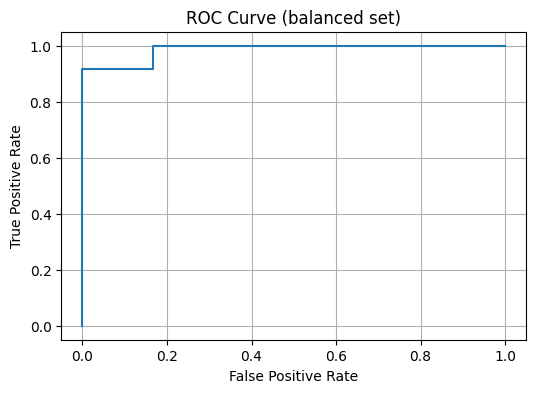

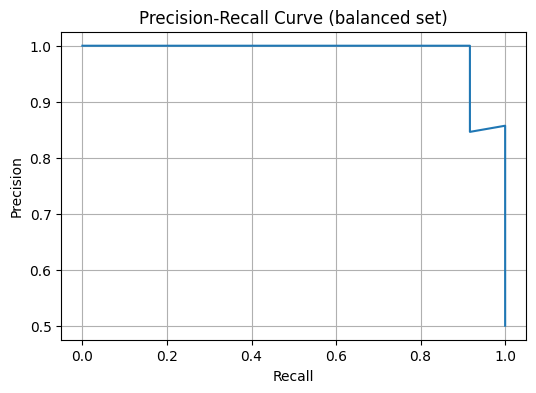

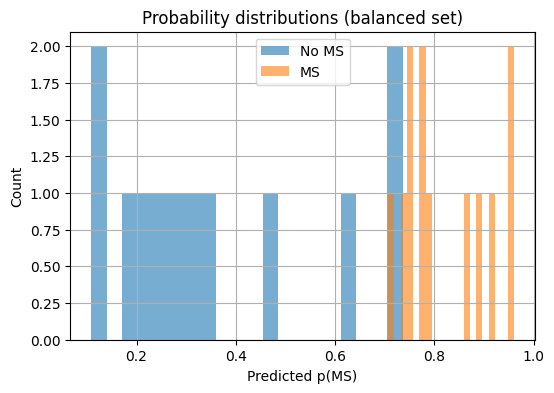

In [48]:
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

from skimage.transform import resize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

# =========================
# CONFIG
# =========================
ROOT_ST  = "/content/drive/My Drive/Semester 10/MS Dataset/MS Conv Network /New Data/DICOM/ST000000/"
SAVE_CSV = "/content/drive/MyDrive/Semester 10/MS Dataset/manual_labels_st000000.csv"
TARGET_HW = (320, 320)

THRESH = 0.46558806
SEED = 42
N_PER_CLASS = None   # None -> auto=min(count_MS, count_NoMS)
BATCH_SIZE = 32

assert os.path.isfile(SAVE_CSV), f"Label CSV not found: {SAVE_CSV}"
assert os.path.isdir(ROOT_ST), f"ROOT_ST not found: {ROOT_ST}"
assert "model" in globals(), "model not loaded."
assert "preprocess_data" in globals(), "preprocess_data(...) not defined."

# =========================
# IO + preprocessing
# =========================
def load_dicom_2d(path: str):
    ds = pydicom.dcmread(path, force=True)
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img
    return img

def preprocess_image_like_training(img_2d: np.ndarray) -> np.ndarray:
    x = preprocess_data(img_2d)  # your pipeline
    x = np.asarray(x)

    if x.ndim == 2:
        x = x[..., None]
    if x.shape[:2] != TARGET_HW:
        x0 = resize(x[..., 0], TARGET_HW, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)
        x = x0[..., None]
    return x.astype(np.float32)

def extract_ms_probs_named(model, X, output_index=0, ms_class_index=0):
    Xin = X
    if hasattr(model, "input_names") and len(model.input_names) == 1:
        Xin = {model.input_names[0]: X}

    raw = model.predict(Xin, verbose=0)
    if isinstance(raw, (list, tuple)):
        raw = raw[output_index]

    raw = np.asarray(raw)
    if raw.ndim == 1:
        p = raw
    elif raw.ndim == 2 and raw.shape[1] == 1:
        p = raw[:, 0]
    else:
        p = raw[:, ms_class_index]
    return p.astype(np.float64)

# =========================
# Load labels and balance
# =========================
df = pd.read_csv(SAVE_CSV)
df = df[df["label"].isin([0, 1])].copy()
assert len(df) > 0, "No labeled samples with label 0/1."

df0 = df[df["label"] == 0].copy()
df1 = df[df["label"] == 1].copy()

n0, n1 = len(df0), len(df1)
print(f"Available labeled: NoMS={n0}, MS={n1}")

n = min(n0, n1) if N_PER_CLASS is None else int(min(N_PER_CLASS, n0, n1))
assert n > 0, "Not enough samples in one class to balance."

rng = np.random.default_rng(SEED)
idx0 = rng.choice(df0.index.to_numpy(), size=n, replace=False)
idx1 = rng.choice(df1.index.to_numpy(), size=n, replace=False)

df_bal = pd.concat([df.loc[idx0], df.loc[idx1]], ignore_index=True)
df_bal = df_bal.sample(frac=1.0, random_state=SEED).reset_index(drop=True)  # shuffle

print(f"Balanced eval set: {len(df_bal)} samples ({n} per class) | seed={SEED}")

# Absolute paths
abs_paths = [os.path.join(ROOT_ST, rp) for rp in df_bal["rel_path"].astype(str).tolist()]
y_true = df_bal["label"].astype(int).to_numpy()

# =========================
# Inference (batched)
# =========================
probs = np.zeros(len(abs_paths), dtype=np.float64)

batch, batch_idx = [], []
for i, path in enumerate(abs_paths):
    img = load_dicom_2d(path)
    x = preprocess_image_like_training(img)
    batch.append(x)
    batch_idx.append(i)

    if len(batch) == BATCH_SIZE or i == len(abs_paths) - 1:
        Xb = np.stack(batch, axis=0)
        pb = extract_ms_probs_named(model, Xb, output_index=0, ms_class_index=0)
        probs[np.array(batch_idx)] = pb
        batch, batch_idx = [], []

y_pred = (probs >= THRESH).astype(int)

# =========================
# Metrics
# =========================
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("\n=== Balanced manual-labeled evaluation (threshold=0.5) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4, zero_division=0))

# Curves (both classes guaranteed)
roc_auc = roc_auc_score(y_true, probs)
ap = average_precision_score(y_true, probs)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"AP (PR-AUC): {ap:.4f}")

fpr, tpr, _ = roc_curve(y_true, probs)
pr, rc, _ = precision_recall_curve(y_true, probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (balanced set)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(rc, pr)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (balanced set)")
plt.grid(True)
plt.show()

# Optional: show summary of probability separation
plt.figure(figsize=(6,4))
plt.hist(probs[y_true==0], bins=20, alpha=0.6, label="No MS")
plt.hist(probs[y_true==1], bins=20, alpha=0.6, label="MS")
plt.xlabel("Predicted p(MS)")
plt.ylabel("Count")
plt.title("Probability distributions (balanced set)")
plt.legend()
plt.grid(True)
plt.show()
